In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rajatsurana979/fast-food-sales-report/Balaji Fast Food Sales.csv
/kaggle/input/datasets/rajatsurana979/fast-food-sales-report/category distribution.JPG


<h1 style="font-size:30px; font-family:Garamond; font-weight:normal; background-color:#FFDB58; color:black; text-align:center; border-radius:100px 100px; padding:20px;">
Importing Libraries and View Data
</h1>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings("ignore")

#  upload csv and view some sample row

In [3]:
df=pd.read_csv("/kaggle/input/datasets/rajatsurana979/fast-food-sales-report/Balaji Fast Food Sales.csv")
df.sample(10)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
144,145,10-09-2022,Sandwich,Fastfood,60,14,840,Online,Mr.,Morning
740,741,7/16/2022,Aalopuri,Fastfood,20,5,100,Online,Mr.,Afternoon
229,230,4/16/2022,Frankie,Fastfood,50,6,300,Online,Mr.,Afternoon
133,134,7/17/2022,Aalopuri,Fastfood,20,12,240,Online,Mrs.,Night
892,893,7/13/2022,Sugarcane juice,Beverages,25,12,300,Cash,Mrs.,Afternoon
425,426,1/20/2023,Frankie,Fastfood,50,14,700,Cash,Mr.,Midnight
475,476,02-02-2023,Aalopuri,Fastfood,20,10,200,Cash,Mr.,Morning
275,276,9/30/2022,Sugarcane juice,Beverages,25,6,150,Cash,Mr.,Midnight
212,213,9/29/2022,Vadapav,Fastfood,20,3,60,NaN,Mrs.,Midnight
990,991,1/18/2023,Sandwich,Fastfood,60,7,420,Cash,Mrs.,Night


# check the columns datatype and not null value count

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

 # Summury of static data columns 

In [5]:
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


<h1 style="font-size:30px; font-family:Garamond; font-weight:normal; background-color:#FFDB58; color:black; text-align:center; border-radius:100px 100px; padding:20px;">
Data Cleaning
</h1>


# Treatement of missing values and duplicate rows

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['transaction_type'].fillna(df['transaction_type'].mode()[0], inplace=True)

In [8]:
df.isnull().sum()

order_id              0
date                  0
item_name             0
item_type             0
item_price            0
quantity              0
transaction_amount    0
transaction_type      0
received_by           0
time_of_sale          0
dtype: int64

# Fix data types and format data according logic or domain 

In [9]:
df['date']=pd.to_datetime(df['date'],format='mixed',dayfirst=True,errors='coerce')

In [10]:
df['received_by'].value_counts()

received_by
Mr.     512
Mrs.    488
Name: count, dtype: int64

In [11]:
df['received_by']=df['received_by'].replace({'Mr.':'Male','Mrs.':'Female'})

# check amount mismatch

In [12]:
df['amount']=df['item_price']*df['quantity']
mismatches=df[df['amount']!=df['transaction_amount']]
print(mismatches)

Empty DataFrame
Columns: [order_id, date, item_name, item_type, item_price, quantity, transaction_amount, transaction_type, received_by, time_of_sale, amount]
Index: []


In [13]:
df.drop(columns=['amount'],inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   object        
 3   item_type           1000 non-null   object        
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   object        
 8   received_by         1000 non-null   object        
 9   time_of_sale        1000 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 78.3+ KB


 **Now here our data is clean and ready to exploration..................**

<h1 style="font-size:30px; font-family:Garamond; font-weight:normal; background-color:#FFDB58; color:black; text-align:center; border-radius:100px 100px; padding:20px;">
EDA by Visualizations
</h1>

# Univariante Analysis

Text(0.5, 1.0, 'Orders by Received By')

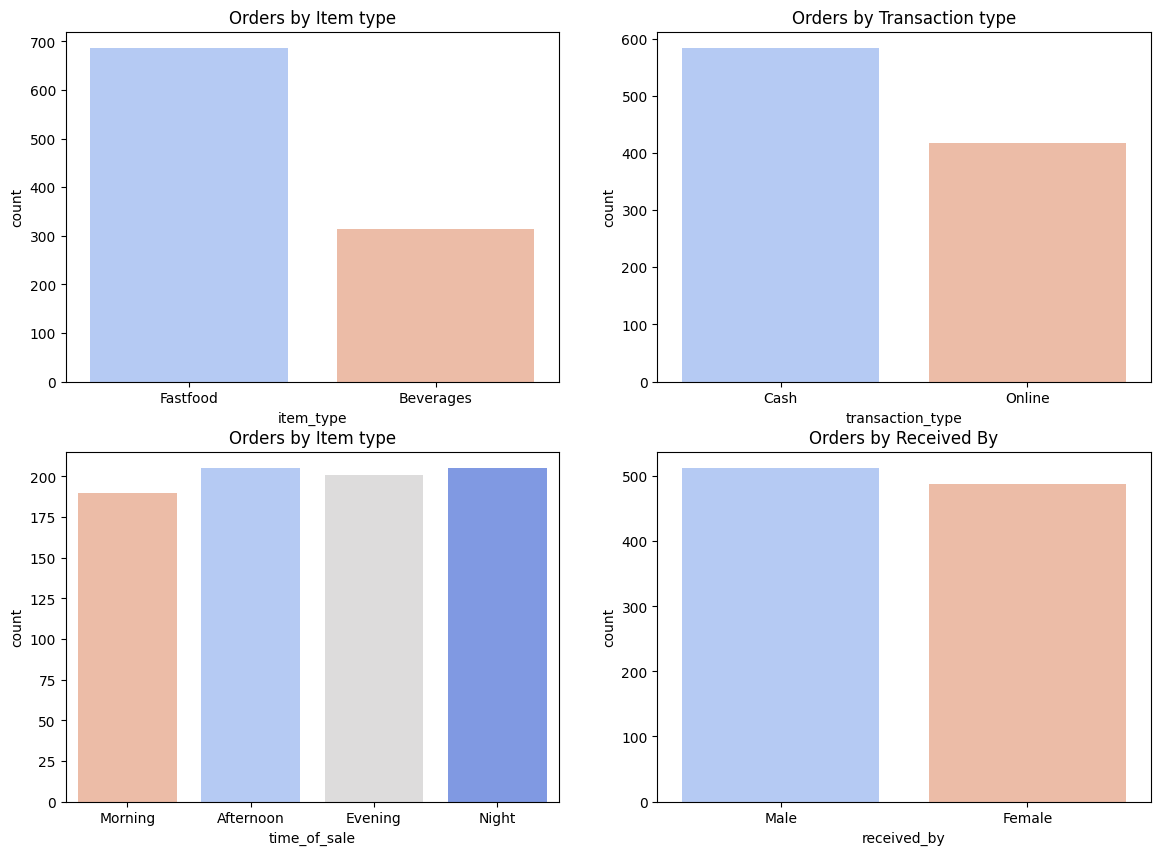

In [15]:
fig,axs=plt.subplots(2,2,figsize=(14,10))

sns.countplot(data=df,x='item_type',hue='item_type',palette='coolwarm',ax=axs[0,0])
axs[0,0].set_title("Orders by Item type")

sns.countplot(data=df,x='transaction_type',hue='transaction_type',palette='coolwarm',ax=axs[0,1])
axs[0,1].set_title("Orders by Transaction type")

sns.countplot(data=df,x='time_of_sale',order=['Morning','Afternoon','Evening','Night'],hue='time_of_sale',palette='coolwarm',ax=axs[1,0])
axs[1,0].set_title("Orders by Item type")

sns.countplot(data=df,x='received_by',hue='received_by',palette='coolwarm',ax=axs[1,1])
axs[1,1].set_title("Orders by Received By")

Text(0.5, 1.0, 'Transaction amount distribution')

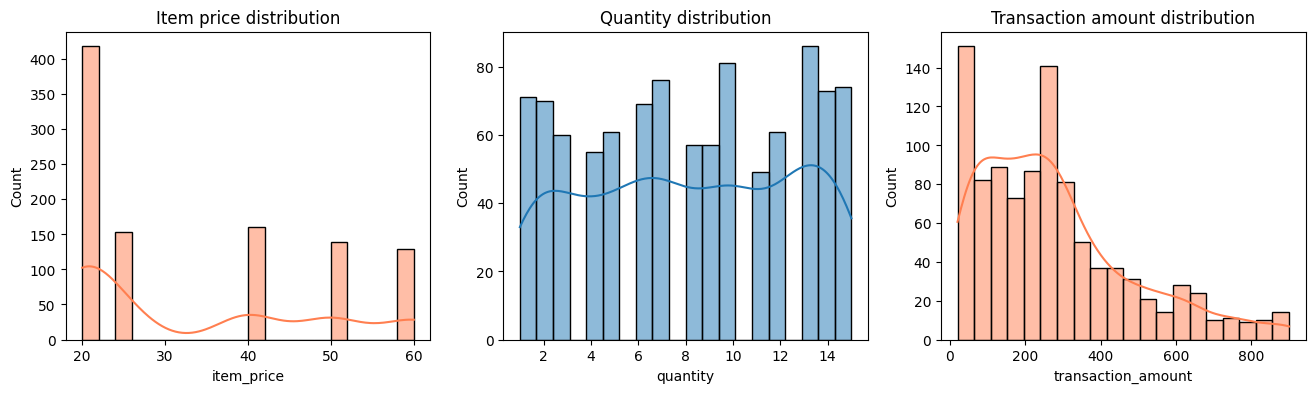

In [16]:
fig,axs=plt.subplots(1,3,figsize=(16,4))
sns.histplot(df['item_price'],bins=20,ax=axs[0],color='coral',kde=True)
axs[0].set_title('Item price distribution')

sns.histplot(df['quantity'],bins=20,ax=axs[1],kde=True)
axs[1].set_title('Quantity distribution')

sns.histplot(df['transaction_amount'],bins=20,color='coral',ax=axs[2],kde=True)
axs[2].set_title('Transaction amount distribution')

# Bivariate analysis and corelation of numric columns

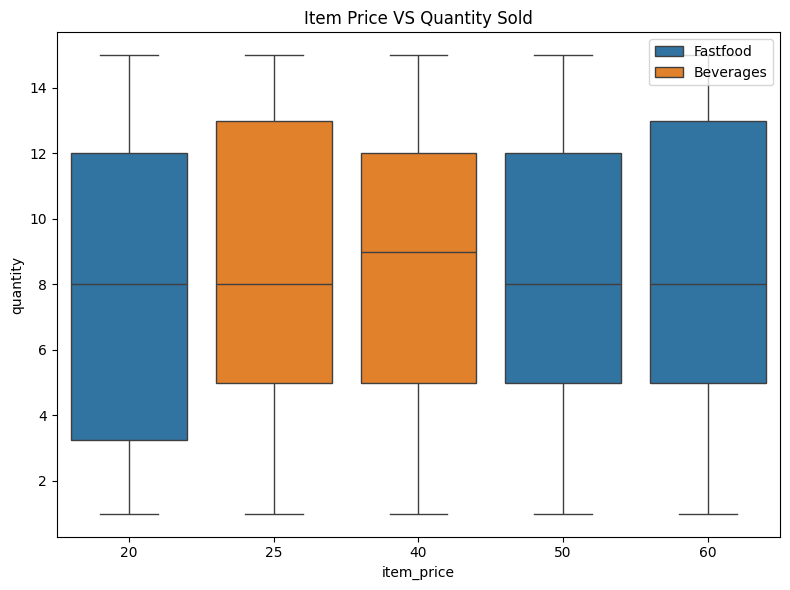

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df,x='item_price',y='quantity',hue='item_type')
plt.title('Item Price VS Quantity Sold')
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

<Axes: >

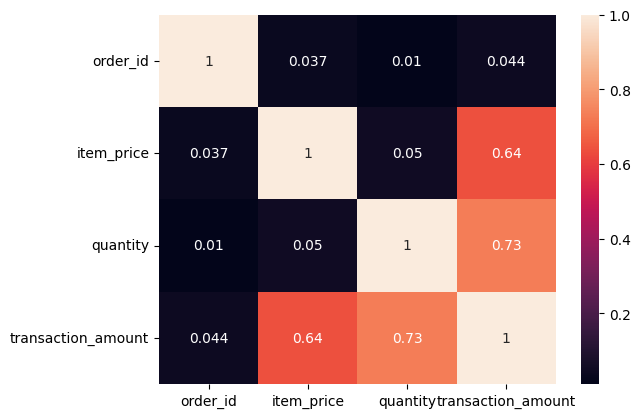

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<h1 style="font-size:30px; font-family:Garamond; font-weight:normal; background-color:#FFDB58; color:black; text-align:center; border-radius:100px 100px; padding:20px;">
Revenue Analysis
</h1>